In [1]:
import json
import pickle
import numpy as np
from copy import deepcopy
from pymatgen.core import Structure
from pymatgen.io.ase import AseAtomsAdaptor
from ase.io.espresso import write_espresso_in

# for plotting if needed
import matplotlib
import matplotlib.pyplot as plt

In [2]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent.parent.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT)) 

from muonscripts.constants import constants

from muonscripts.io_tools.read import read_cif
from muonscripts.io_tools.read import read_from_file

from muonscripts.io_tools.load_relax import load_relax
from muonscripts.io_tools.load_relax import save_relax_results
from muonscripts.io_tools.load_relax import load_relax_results
from muonscripts.io_tools.find_qe_files import select_groups
from muonscripts.io_tools.find_qe_files import get_relax_after_run
from muonscripts.io_tools.find_qe_files import print_relax_summary
from muonscripts.io_tools.find_qe_files import load_relax_from_folder

from muonscripts.undi_tools.second_moments_avg import second_moments_fn
from muonscripts.undi_tools.second_moments import zero_field_distribution_powder

from muonscripts.undi_tools.atoms_scaling import scale_neighbors, partition_into_shells
from muonscripts.undi_tools.atoms_scaling import only_muon_cluster, compute_zeta_cluster

from muonscripts.undi_tools.atoms import build_undi_neighbors, build_undi_neighbors_from_file
from muonscripts.undi_tools.atoms import complete_undi_neighbors, neighbors_hilbert_dimension

from muonscripts.efg.point_charge import compute_efg
from muonscripts.efg.point_charge import sphere_radius_convergence
from muonscripts.efg.point_charge import build_point_charge_efg_neighbors

# from muonscripts.efg.utils import nu_Q, quadrupole_frequencies, get_omegaQ_mu
# from muonscripts.efg.point_charge import compute_efg, point_charge_EFG, diagonalize_EFG, atom_dict_EFG

from muonscripts.muon_tools.displacements import radial_to_dict
from muonscripts.muon_tools.displacements import max_displacement
from muonscripts.muon_tools.displacements import select_radial_displacement

from muonscripts.muon_tools.aiida_muon.sites_supercells import gensup
from muonscripts.muon_tools.aiida_muon.sites_supercells import niche_add_impurities
from muonscripts.muon_tools.aiida_muon.sites_supercells import compute_suggest_supercell_size

from muonscripts.muon_tools.aiida_muon.distortions import get_distortions
from muonscripts.muon_tools.aiida_muon.clustering import get_clustering_after_run_from_data

from muonscripts.muon_tools.aiida_muon.clustering_report import print_clustering_summary

from muonscripts.muesr_tools.local_fields import pfields, rfields

In [3]:
def load_raw_data_only(filename, x_min=0):
    """Reads the first 2-3 columns (xData, Data, [errData]) of a muSR
    data file, ignoring any other (e.g. theory) columns."""
    import pandas as pd
    
    df = pd.read_csv(filename, skipinitialspace=True)
    df = df.replace(r"^\s*$", np.nan, regex=True)
    cols = list(df.columns[:3])
    d = df[cols].dropna()
    xData = d[cols[0]].to_numpy(dtype=float)
    yData = d[cols[1]].to_numpy(dtype=float)
    errData = d[cols[2]].to_numpy(dtype=float) if len(cols) > 2 else None
    if x_min is not None:
        keep = xData >= x_min
        xData, yData = xData[keep], yData[keep]
        if errData is not None:
            errData = errData[keep]
    return xData, yData, errData


def _ordered_legend(ax, order_list, **legend_kwargs):
    handles, labels = ax.get_legend_handles_labels()

    def priority(label):
        for i, key in enumerate(order_list):
            if key in label:
                return i
        return len(order_list)

    entries = sorted(
        zip(handles, labels),
        key=lambda e: priority(e[1])
    )

    handles, labels = zip(*entries)

    return ax.legend(handles, labels, **legend_kwargs)

In [4]:
def powder_celio_signal(
    neighbors, 
    tlist, 
    k=2, 
    nrep=1,
    single_precision=False, 
    algorithm='light',
    log_level='',
    undi_path='/home/misah/projects/myproject/undi'
):
    """Powder-averaged P_z^mu(t) via undi.py's celio_on_steroids(), using
    the SAME exact 3-orthogonal-axis trick as the exact-diagonalization
    path elsewhere in this thread (mathematically exact for zero-field
    muon depolarization, independent of which method solves the
    dynamics underneath -- see wilkinson_prl_example.py's derivation).

    REQUIRES the compiled backend (fast_quantum_light or similar) that
    ships with the full `undi` package -- NOT importable from just
    undi.py + isotopes.py as used elsewhere in this thread. If you see
    ImportError here, you need `pip install undi` (or build the C++
    extensions from the undi source repo) rather than just using the
    loose undi.py file.

    nrep : int
        Number of independent Celio stochastic repeats to average over
        (in ADDITION to averaging over the 3 powder directions) -- more
        repeats reduce the Monte Carlo noise in the result. The paper's
        own SM mentions similar repeat-averaging for their Celio-based
        A15 simulations.
    """
    # Importing stuff...
    try:
        from undi import MuonNuclearInteraction
    except (ImportError, ModuleNotFoundError):
        import sys
        sys.path.append(undi_path)
        from undi import MuonNuclearInteraction

    signal = np.zeros(len(tlist))
    for direction in ([1, 0, 0], [0, 1, 0], [0, 0, 1]): # simple powder average
        NS = MuonNuclearInteraction(neighbors, log_level=log_level)
        NS.translate_rotate_sample_vec(direction)   # rotates geometry directly
        for _ in range(nrep):
            signal += NS.celio_on_steroids(
                tlist, k=k, single_precision=single_precision, progress=False, algorithm=algorithm
            )
    return signal / (3 * nrep)

In [5]:
def kubo_toyabe(tlist, Gmu_S2):
    """Calculates the Kubo-Toyabe polarization for the nuclear arrangement
        provided in input.

    Parameters
    ----------
    tlist : numpy.array
        List of times at which the muon polarization is observed.
    Gmu_S2 : float
        The product of gamma_mu and sigma^2.

    Returns
    -------
    numpy.array
        Kubo-Toyabe function, for a powder in zero field.
    """
    return 0.333333333333 + 0.6666666666 * \
            (1- Gmu_S2  *  np.power(tlist,2)) * \
            np.exp( - 0.5 * Gmu_S2 * np.power(tlist,2))

In [6]:
import os
dpath='./'

In [7]:
filename = 'UCoGe.cif'
filename = os.path.join(dpath, filename)
st = Structure.from_file(filename)

st

Structure Summary
Lattice
    abc : 6.8472 7.2296 4.2109
 angles : 90.0 90.0 90.0
 volume : 208.450149340608
      A : np.float64(6.8472) np.float64(0.0) np.float64(4.192700781560878e-16)
      B : np.float64(1.162608350810221e-15) np.float64(7.2296) np.float64(4.426853249557852e-16)
      C : np.float64(0.0) np.float64(0.0) np.float64(4.2109)
    pbc : True True True
PeriodicSite: U1 (U) (0.06162, 5.111, 1.053) [0.009, 0.707, 0.25]
PeriodicSite: U1 (U) (3.362, 1.497, 3.158) [0.491, 0.207, 0.75]
PeriodicSite: U1 (U) (3.485, 5.733, 1.053) [0.509, 0.793, 0.25]
PeriodicSite: U1 (U) (6.786, 2.118, 3.158) [0.991, 0.293, 0.75]
PeriodicSite: Co1 (Co) (1.98, 3.023, 1.053) [0.2891, 0.4181, 0.25]
PeriodicSite: Co1 (Co) (1.444, 6.637, 3.158) [0.2109, 0.9181, 0.75]
PeriodicSite: Co1 (Co) (5.403, 0.5921, 1.053) [0.7891, 0.0819, 0.25]
PeriodicSite: Co1 (Co) (4.868, 4.207, 3.158) [0.7109, 0.5819, 0.75]
PeriodicSite: Ge1 (Ge) (1.342, 0.629, 1.053) [0.196, 0.087, 0.25]
PeriodicSite: Ge1 (Ge) (2.082, 4.

In [8]:
spacing = 2.0
distance = 1.0

sc_matrix = [
    [2, 0, 0], 
    [0, 2, 0], 
    [0, 0, 3]
    ]

In [9]:
mu_list = niche_add_impurities(
    structure=st,
    niche_atom='H',
    niche_spacing=spacing,
    niche_distance=distance,
    verbose=False,
)
print('Number of muon sites generated:', len(mu_list))
mu_list

Number of muon sites generated: 10


[array([0.001, 0.001, 0.001]),
 array([0.001     , 0.001     , 0.33433333]),
 array([0.251, 0.001, 0.001]),
 array([0.501, 0.001, 0.001]),
 array([0.501     , 0.001     , 0.33433333]),
 array([0.001, 0.251, 0.001]),
 array([0.001     , 0.251     , 0.33433333]),
 array([0.251, 0.251, 0.001]),
 array([0.251     , 0.251     , 0.33433333]),
 array([0.251     , 0.251     , 0.66766667])]

In [10]:
# Add positions to original structure
stc = st.copy()
for p in mu_list:
    stc.append('H', p)

filename='UCoGe_initial_muonsites.cif'
print('Writing muon sites to:', filename)
filename=os.path.join(dpath, filename)
stc.to(fmt='cif', filename=filename)

Writing muon sites to: UCoGe_initial_muonsites.cif


/home/misah/.virtualenvs/pyqm/lib/python3.10/site-packages/pymatgen/core/structure.py:2945: UserWarning: Site labels are not unique, which is not compliant with the CIF spec (https://www.iucr.org/__data/iucr/cifdic_html/1/cif_core.dic/Iatom_site_label.html):`['U1', 'U1', 'U1', 'U1', 'Co1', 'Co1', 'Co1', 'Co1', 'Ge1', 'Ge1', 'Ge1', 'Ge1', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21']`.
  writer: Any = CifWriter(self, **kwargs)


"# generated using pymatgen\ndata_U2Co2Ge2H5\n_symmetry_space_group_name_H-M   'P 1'\n_cell_length_a   6.84720000\n_cell_length_b   7.22960000\n_cell_length_c   4.21090000\n_cell_angle_alpha   90.00000000\n_cell_angle_beta   90.00000000\n_cell_angle_gamma   90.00000000\n_symmetry_Int_Tables_number   1\n_chemical_formula_structural   U2Co2Ge2H5\n_chemical_formula_sum   'U4 Co4 Ge4 H10'\n_cell_volume   208.45014934\n_cell_formula_units_Z   2\nloop_\n _symmetry_equiv_pos_site_id\n _symmetry_equiv_pos_as_xyz\n  1  'x, y, z'\nloop_\n _atom_site_type_symbol\n _atom_site_label\n _atom_site_symmetry_multiplicity\n _atom_site_fract_x\n _atom_site_fract_y\n _atom_site_fract_z\n _atom_site_occupancy\n  U  U1  1  0.00900000  0.70700000  0.25000000  1.0\n  U  U1  1  0.49100000  0.20700000  0.75000000  1.0\n  U  U1  1  0.50900000  0.79300000  0.25000000  1.0\n  U  U1  1  0.99100000  0.29300000  0.75000000  1.0\n  Co  Co1  1  0.28910000  0.41810000  0.25000000  1.0\n  Co  Co1  1  0.21090000  0.918100

In [11]:
supc_list = gensup(
    p_st=st, 
    mu_list=mu_list, 
    sc_mat=sc_matrix,
    only_one_cell = False,
    validate_proximity=True
    )
print('Number of supercells generated:', len(supc_list))
# supc_list

Number of supercells generated: 10


In [12]:
DEFAULT_QE_RELAX_NAMELISTS  = {
    'control': 
    {
        'calculation': 'relax',
        'etot_conv_thr': 0.0001,
        'forc_conv_thr': 0.001,
        'max_seconds': 604800,
        'nstep': 300,
        'outdir': '/scratch/jaz/ucoge',
        'prefix': 'ucoge',
        'pseudo_dir': '/home/vol05/scarf795/pseudo/gbrv',
        'restart_mode': 'from_scratch',
        'tprnfor': True,
        'tstress': True,
        'verbosity': 'high',
        'wf_collect': True
    },

    'system': 
    {
        'degauss': 0.005,
        'ecutrho': 600.0,
        'ecutwfc': 60.0,
        # 'ibrav': 0,
        # 'nat': 145,
        # 'ntyp': 4,
        'nosym': False,
        'occupations': 'smearing',
        'smearing': 'gaussian',
        'tot_charge': 0.0
    },

    'electrons': 
    {
        'conv_thr': 1e-07,
        'electron_maxstep': 800,
        'mixing_beta': 0.3,
        'mixing_mode': 'local-tf'
    },

    'ions': {}
}

pseudos = {
    "U": "U.pbe-spfn-rrkjus_psl.1.0.0.UPF",
    "Co": "co_pbe_v1.2.uspp.F.UPF",
    "Ge": "ge_pbe_v1.4.uspp.F.UPF",
    "H": "h_pbe_v1.4.uspp.F.UPF",
}

kpoints_kspacing = 0.3 # A?-1

In [13]:
for idx, supc in enumerate(supc_list):
    ase_atoms = AseAtomsAdaptor.get_atoms(supc)
    fname = f'ucoge_muon_{idx+1}.in'
    fname = f'{idx+1}.in'
    print('Creating input file:', fname)
    subpath = os.path.join(dpath, 'input_tmpl')
    fname = os.path.join(subpath, fname)

    prefix = f'UCG_mun_{idx+1}'
    input_data = deepcopy(DEFAULT_QE_RELAX_NAMELISTS)
    input_data['control']['prefix'] = prefix

    write_espresso_in(
        fname,
        atoms=ase_atoms,
        input_data=input_data,
        # kspacing=kpoints_kspacing,
        kpts=(2, 2, 2),
        koff=(0, 0, 0),
        pseudopotentials=pseudos,
        crystal_coordinates=True
    )

Creating input file: 1.in
Creating input file: 2.in
Creating input file: 3.in
Creating input file: 4.in
Creating input file: 5.in
Creating input file: 6.in
Creating input file: 7.in
Creating input file: 8.in
Creating input file: 9.in
Creating input file: 10.in


In [14]:
preview = True

pattern="*.out"
check_input = True
calc_types = "relax"

folder1 = os.path.join(dpath, 'query/mu+')

if preview:
    groups = get_relax_after_run(
        folder1, 
        pattern=pattern, 
        check_input=check_input,
        calc_types=calc_types, 
        verbose=False,
    )
    print(f"\nPreview: {len(groups)} system group(s) found "
            f"(selection filters ignored in preview mode)\n")
    print_relax_summary(groups)


results1 = load_relax(
    path=folder1,
    pattern=pattern,
    check_input=check_input,
    calc_types=calc_types,
    group_by_system=True,
    pymatgen=True,
    verbose=True,
    # **select_kwargs
)

file = 'UCoGe_muonchargepositive.pkl'
file = os.path.join(dpath, file)
save_relax_results(results1, file, fmt='pickle')


Preview: 1 system group(s) found (selection filters ignored in preview mode)

  Co-Ge-H-U  nat = 145  ntyp = 4  -> 4 converged runs
  ---------------------------------------
  1 distinct system(s), 4 converged run(s) total
Saved 4 result(s) to UCoGe_muonchargepositive.pkl (pickle)


In [15]:
# file = 'UCoGe_muonchargepositive.pkl'
# file = os.path.join(dpath, file)

# data = load_relax_results(file, fmt='pickle')

# idx = 0
# d = data[idx]

# Structure.from_dict(d["rlxd_struct"])

In [16]:
input_st = st.copy()
init_supc = input_st.copy()
init_supc.make_supercell(sc_matrix)

cluster = get_clustering_after_run_from_data(
    results1, 
    input_st, 
    sc_matrix, 
    magmom=None
)

print('The cluster keys are:', list(cluster.keys()))

mapping = cluster["mapping"]
unique_cluster = cluster["unique_pos"]

unique_cluster

unique_sorted = {v: i+1 for i, v in enumerate(sorted(set(mapping)))}
remapped = [unique_sorted[x] for x in mapping]

remapped, remapped

print_clustering_summary(
    cluster, 
    input_st=input_st,   # or None, if you want the supercell positions
    use_unitcell=False,   # or None, if you want the supercell positions
    # precision=5
)

The cluster keys are: ['unique_pos', 'mag_inequivalent', 'mapping']

UNIQUE MUON SITES (supercell frac. coordinates)
  #        idx        frac_x        frac_y        frac_z       dE (eV)
----------------------------------------------------------------------
  0          4       0.28204       0.04166       0.08208       0.00000
  1          1      -0.02612       0.08393       0.08151       0.34335
----------------------------------------------------------------------
Total unique sites: 2

MAGNETICALLY INEQUIVALENT SITES PENDING CALCULATION (0) (supercell frac. coordinates)
  (none -- all magnetically inequivalent sites already covered)


In [17]:
file = '1.in' # highest energy site
file = '4.in' # lowest energy site
file = os.path.join(folder1, file)
inp_ase  = read_from_file(file, format="espresso-in")
inp_ase2 = inp_ase.copy() 

In [18]:
file = '1.out' # highest energy site
file = '4.out' # lowest energy site
file = os.path.join(folder1, file)
rlx_ase  = read_from_file(file, format="espresso-out", index=-1)
rlx_ase2 = rlx_ase.copy()

In [19]:
# get and remove muon position
rlx_ase2 =  rlx_ase.copy()
if 1 not in rlx_ase2.numbers:
    raise ValueError("No Hydrogen (atomic number 1) found in rlx_ase2.")
mu_idx = np.where(rlx_ase2.numbers == 1)[0][-1]
mupos_rlx = rlx_ase2.get_scaled_positions()[mu_idx]
del rlx_ase2[mu_idx]

mupos_rlx

array([0.28204478, 0.04165768, 0.08207603])

In [20]:
cutoffs_deep = {'U': 3.0, 'Co': 3.53,}# 'Ge': 2.0}
sm_contribs = second_moments_fn(
    atoms=rlx_ase2.copy(), 
    muon_position=mupos_rlx, 
    cutoff=cutoffs_deep
)
Gmu_S2 = sum(sm_contribs.values())

print('Contributions to the total second moment (sigma^2) from each nuclear species:')
width = max((len(s) for s in sm_contribs), default=5)
width = max(width, len('Total'))

# Loop over species and print absolute + percentage contributions
for symbol, val in sm_contribs.items():
    pct = (val / Gmu_S2) * 100 if Gmu_S2 > 0 else 0.0
    print(f"  {symbol:>{width}s}: {val:20.6f} (rad^2/s^2) | {pct:7.3f}%")
print(f"  {'Total':>{width}s}: {Gmu_S2:20.6f} (rad^2/s^2) | 100.000%")
print(f"")

Contributions to the total second moment (sigma^2) from each nuclear species:
     Co:  137779636559.796661 (rad^2/s^2) |  99.923%
     Ge:     101910074.882524 (rad^2/s^2) |   0.074%
      U:       3624625.590229 (rad^2/s^2) |   0.003%
  Total:  137885171260.269440 (rad^2/s^2) | 100.000%



In [21]:
print(f"The Delta value is = {np.sqrt(Gmu_S2)*1e-6:.4f} us^-1")

The Delta value is = 0.3713 us^-1


In [22]:
inf_cutoff=10
cutoffs = {'U': 3.0, 'Co': 3.53,}# 'Ge': 2.0}
cutoffs = {'U': 3.0, 'Co': 3.53,}# 'Ge': 2.0}
cutoffs = {'Co': 3.50,}
print("== Building neighbor cluster ==")
neighbors = build_undi_neighbors(
    rlx_ase2,
    mupos_rlx,
    cutoffs=cutoffs,
    inf_cutoff=inf_cutoff,
    efg_tensors=None,
    efg_factor=1.0,
    gamma_overrides=None,
    isotope_overrides={'U': '235U', 'Co': '59Co', 'Ge': '73Ge'},
    quadrupole_moments_overrides=None,
    verbose_neighbors=True,
    # format='elk'
    # **read_kwargs,
)

# complete missing nuclear properties
neighbors = complete_undi_neighbors(neighbors, log_level="")

neighbors

neighbors_hilbert_dimension(neighbors)

== Building neighbor cluster ==
Adding atom #48  Co   with position (Å): [ -2.0120,   2.4126,  -0.0104] and distance: 3.1415 Å
[override] isotope: Co -> 59Co
Adding atom #72  Co   with position (Å): [  1.7214,   0.0686,   0.0107] and distance: 1.7228 Å
[override] isotope: Co -> 59Co
Adding atom #63  Co   with position (Å): [ -2.3633,  -1.1851,   2.1347] and distance: 3.3980 Å
[override] isotope: Co -> 59Co
Adding atom #65  Co   with position (Å): [ -2.3784,  -1.1881,  -2.1203] and distance: 3.4006 Å
[override] isotope: Co -> 59Co


8192

In [23]:
original_neighbors = neighbors.copy()

In [24]:
# CONFIGURATION SWITCHES
USE_FORMAL_CHARGES = True    # True: Set A (+3/-1/-2) | False: Set B (+1.2/-0.6/-0.6)
APPLY_STERNHEIMER  = True     # True: apply (1 - gamma_inf) correction | False: raw lattice EFG
INCLUDE_MUON       = True     # Set True if computing EFG with the muon present


# Define Charge Sets
if USE_FORMAL_CHARGES:
    UCoGe_charges = {
        'U':  +3.0,
        'Co': -1.0,
        'Ge': -2.0,
        # 'H':  +1.0   # Muon site charge (optional)
    }
    print("Running with FORMAL / NOMINAL charges: U=+3, Co=-1, Ge=-2")
else:
    UCoGe_charges = {
        'U':  +1.2,
        'Co': -0.6,
        'Ge': -0.6,
        # 'H':  +1.0   # Muon site charge (optional)
    }
    print("Running with HYBRIDIZED / BADER charges: U=+1.2, Co=-0.6, Ge=-0.6")


# Define Sternheimer Antishielding Factors (gamma_infinity)
# Values derived from atomic HF calculations (Sternheimer factors)
sternheimer_gamma_inf = {
    'Co': -9.00,   # Typical factor for Cobalt ions (~ -9 to -12)
    'Ge': -18.0,   # Germanium factor
    'U':  -80.0,   # Actinide heavy core (very large amplification)
    'H':   0.0     # Proton/Muon has no core electrons (gamma_inf = 0)
}
"""VARIOUS Reference for Sternheimer antishielding factor of Co
Value  | Reference
----------------
-7     | T. P. Das and M. Pomerantz, Phys. Rev. 123,2070 (1961) --> Table I
-8.85  | K. D. Sen and P. T. Narasimhan, Phys. Rev. A 14, 539 (1976) --> Tabel I
-7.63  | R. P. Gupta and S. K. Sen, Phys. Rev. B 12, 15 (1975) --> Tabel I

"""
sphere_radius = 60
include_efg = True

# only interested on 'Co'
gamma_sternheimer = 0
if APPLY_STERNHEIMER:
    gamma_sternheimer = sternheimer_gamma_inf['Co']
gamma_sternheimer

Running with FORMAL / NOMINAL charges: U=+3, Co=-1, Ge=-2


-9.0

In [25]:
neighbors = scale_neighbors(
    original_neighbors.copy(), scale=1+(0/100), mode="multiplicative", include_muon=True
)

quadrupolar_neighbors = build_point_charge_efg_neighbors(
    rlx_ase2,
    neighbors=neighbors.copy(),
    muon_position=mupos_rlx,
    atomic_charges=UCoGe_charges,
    sphere_radius=sphere_radius,
    gamma_sternheimer=gamma_sternheimer,
    include_nuclear_efg=include_efg,
    remove_efg_noise=False,
    efg_factor=1.0+(0/100), # trying to enlarge EFG values by 0%, 5%, 10%, ...
    efg_verbose=True,
    include_muon=True
)
quadrupolar_original_neighbors =  quadrupolar_neighbors.copy()

---- point charge EFG: lattice sum for 52115 charges within sphere radius 60.000 Å ----
---- point charge EFG: lattice sum for 52087 charges within sphere radius 60.000 Å ----
---- point charge EFG: lattice sum for 52111 charges within sphere radius 60.000 Å ----
---- point charge EFG: lattice sum for 52111 charges within sphere radius 60.000 Å ----


In [26]:
neighbors_scaled = scale_neighbors(
    original_neighbors.copy(), scale=1+(2/100), mode="multiplicative", include_muon=True
)

quadrupolar_neighbors_scaled = build_point_charge_efg_neighbors(
    rlx_ase2,
    neighbors=neighbors_scaled.copy(),
    muon_position=mupos_rlx,
    atomic_charges=UCoGe_charges,
    sphere_radius=sphere_radius,
    gamma_sternheimer=gamma_sternheimer,
    include_nuclear_efg=include_efg,
    remove_efg_noise=False,
    efg_factor=1.0+(0/100), # trying to enlarge EFG values by 0%, 5%, 10%, ...
    efg_verbose=True,
    include_muon=True
)

---- point charge EFG: lattice sum for 52095 charges within sphere radius 60.000 Å ----
---- point charge EFG: lattice sum for 52095 charges within sphere radius 60.000 Å ----
---- point charge EFG: lattice sum for 52118 charges within sphere radius 60.000 Å ----
---- point charge EFG: lattice sum for 52114 charges within sphere radius 60.000 Å ----


In [27]:
def compare_neighbors_positions(original, scaled):
    """
    Compare nuclear positions before and after scaling.
    """

    for old, new in zip(original, scaled):

        label = old["Label"]

        if label == "mu":
            continue

        r_old = np.linalg.norm(old["Position"])
        r_new = np.linalg.norm(new["Position"])
        rel_dif = np.linalg.norm(new["Position"]-old["Position"])

        ang = 1e-10
        print(
            f"{label:>5s}  "
            f"|R_old| = {r_old/ang:.6f} Å   "
            f"|R_new| = {r_new/ang:.6f} Å   "
            # f"|R_new|-|R_old| = {(r_new-r_old)/ang: .6f} Å   "
            f"|R_new-R_old| = {rel_dif/ang:.6f} Å   "
            f"|R_new|/|R_old| = {r_new/r_old:.4f}"
        )

scaled_neighbors = scale_neighbors(
    original_neighbors.copy(), scale=1+(2/100), mode="multiplicative", include_muon=True
)
compare_neighbors_positions(original_neighbors, scaled_neighbors)

 59Co  |R_old| = 3.141489 Å   |R_new| = 3.204318 Å   |R_new-R_old| = 0.062830 Å   |R_new|/|R_old| = 1.0200
 59Co  |R_old| = 1.722812 Å   |R_new| = 1.757268 Å   |R_new-R_old| = 0.034456 Å   |R_new|/|R_old| = 1.0200
 59Co  |R_old| = 3.398011 Å   |R_new| = 3.465972 Å   |R_new-R_old| = 0.067960 Å   |R_new|/|R_old| = 1.0200
 59Co  |R_old| = 3.400578 Å   |R_new| = 3.468589 Å   |R_new-R_old| = 0.068012 Å   |R_new|/|R_old| = 1.0200


In [28]:
# Time values, in seconds
tlist = np.linspace(0, 8e-6, 1000)
# tlist = np.linspace(0.0, 15e-6, 101)
tlist_us = tlist*1e6

In [29]:
signal_DIP = powder_celio_signal(
    original_neighbors.copy(), tlist=tlist, k=4, nrep=4, single_precision=True, algorithm='fast')

Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


In [30]:
signal_DIP_enlarged = powder_celio_signal(
    neighbors_scaled.copy(), tlist=tlist, k=4, nrep=4, single_precision=True, algorithm='fast')

Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


In [31]:
signal_PCEFG = powder_celio_signal(
    quadrupolar_original_neighbors, tlist=tlist, k=4, nrep=4, single_precision=True, algorithm='fast')

Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


In [32]:
signal_PCEFG_enlarged = powder_celio_signal(
    quadrupolar_neighbors_scaled, tlist=tlist, k=4, nrep=4, single_precision=True, algorithm='fast')

Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co
Warning, overriding gamma for 59Co
Warning, overriding quadrupole moment for 59Co


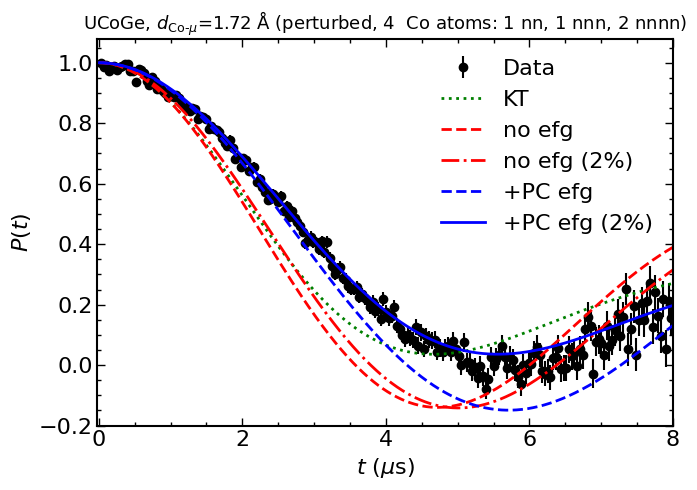

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))

file = 'UCoGe_ZFmuSR_6K.dat'
file = os.path.join(dpath, file)
xData, yData, errData = load_raw_data_only(file, x_min=0.0)   # drop the t<0 "prompt" artifact bin
# print(len(yData))
ax.errorbar(xData, yData/yData.max(), yerr=errData/yData.max(), fmt='o', color='black', alpha=1.0, ms=6, label='Data')
ax.errorbar(tlist_us, kubo_toyabe(tlist, Gmu_S2=Gmu_S2), color='green', ls=':', lw=2, label=r'KT')
ax.errorbar(tlist_us, signal_DIP, color='red', ls='--', lw=2, label=r'no efg')
ax.errorbar(tlist_us, signal_DIP_enlarged, color='red', ls='-.', lw=2, label=r'no efg (2%)')
ax.errorbar(tlist_us, signal_PCEFG, color='b', ls='--', lw=2, label=r'+PC efg')
ax.errorbar(tlist_us, signal_PCEFG_enlarged, color='b', ls='-', lw=2, label=r'+PC efg (2%)')

fontsize=16

ax.set_title(r"UCoGe, $d_{\mathrm{Co}\text{-}{\mu}}$=1.72 Å (perturbed, 4  Co atoms: 1 nn, 1 nnn, 2 nnnn)", fontsize=fontsize-3)
# ax.set_title(r"V$_3$Si, $d_{\mathrm{V}\text{-}{\mu}}$=1.7553 Å (perturbed, 4 nn V)", fontsize=fontsize-3)

ax.set_xlabel(r"$t$ ($\mu$s)", fontsize=fontsize)
ax.set_ylabel(r"$P(t)$", fontsize=fontsize)

ax.set_xlim([-0.02, 8.00])
ax.set_ylim([-0.20, 1.08])


for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.minorticks_on()
ax.tick_params(
    axis="both",
    which="major",
    direction="in",
    top=True,
    right=True,
    length=6,
    width=1.0,
    labelsize=fontsize,
)
ax.tick_params(
    axis="both",
    which="minor",
    direction="in",
    top=True,
    right=True,
    length=3,
    width=1.0,
)

prop={'size': 16, 'weight':'normal'}
handler_map={
    tuple: matplotlib.legend_handler.HandlerTuple(ndivide=5, pad=1), # ndivide=None
}
_ordered_legend(ax, order_list=('Data', ), prop=prop, frameon=False, handler_map=handler_map)
# ax.legend()

plt.tight_layout()
figname='UCoGe_computed_polarization.png'
figname=os.path.join(dpath, figname)
plt.savefig(figname)
plt.show()

In [34]:
"""
1. The agreement between data and simulation including point-charge (PC)
EFG is not perfect, but the the dip position is clearly well reproduced.

2. The perturbed mu-X distances are enlarged by 2%, including PC-EFG shows
a much better agreements.

However, the shape of KT-like behavior above requires this approach to properly
consider the quadrupolar interaction contribution.
"""

'\n1. The agreement between data and simulation including point-charge (PC)\nEFG is not perfect, but the the dip position is clearly well reproduced.\n\n2. The perturbed mu-X distances are enlarged by 2%, including PC-EFG shows\na much better agreements.\n\nHowever, the shape of KT-like behavior above requires this approach to properly\nconsider the quadrupolar interaction contribution.\n'

In [60]:
idx = 0
d = unique_cluster[idx]

rlx_supst = Structure.from_dict(d["rlxd_struct"])

p_st = st.copy()

U_idx = [i for i, site in enumerate(p_st) if site.specie.name == 'U']
Co_idx = [i for i, site in enumerate(p_st) if site.specie.name == 'Co']

# define magnetic moments
spin_dir = [0, 0.07, 0] # in muB
magmoms = np.zeros((len(p_st), 3))
# magmoms[Co_idx] = spin_dir # small ordered moments on Co atoms
magmoms[U_idx] = spin_dir    # small ordered moments on U atoms

fields_r = rfields(
    p_st=p_st.copy(),
    magmoms=magmoms,
    sc_mat=sc_matrix,
    r_supst=rlx_supst,
    cont_field=-0.005,
    muon_label="H",
)
fields_r.total_norm, fields_r.dipolar_norm, fields_r.lorentz_norm, fields_r.muon_positions

(array([0.00502601]),
 array([0.00480885]),
 array([0.00521812]),
 array([[0.28204478, 0.04165768, 0.08207603]]))

In [44]:
np.dot(fields_r.muon_positions, sc_matrix)

array([[0.56408957, 0.08331537, 0.24622808]])

In [55]:
fields_p = pfields(
    structure=p_st.copy(),
    magmoms=magmoms,
    # muon_pos=np.dot(fields_r.muon_positions, sc_matrix),
    muon_pos=[0, 0, 0],
    cont_field=-0.005,
    include_equivalent_sites=True,
    muon_label="H",
)
fields_p.total_norm, fields_p.dipolar_norm, fields_p.lorentz_norm, fields_p.muon_positions

(array([0.01483463, 0.01483463, 0.01483463, 0.01483463]),
 array([0.01466634, 0.01466634, 0.01466634, 0.01466634]),
 array([0.00521867, 0.00521867, 0.00521867, 0.00521867]),
 array([[0. , 0. , 0. ],
        [0.5, 0.5, 0. ],
        [0.5, 0.5, 0.5],
        [0. , 0. , 0.5]]))

In [38]:
p_st

Structure Summary
Lattice
    abc : 6.8472 7.2296 4.2109
 angles : 90.0 90.0 90.0
 volume : 208.450149340608
      A : np.float64(6.8472) np.float64(0.0) np.float64(4.192700781560878e-16)
      B : np.float64(1.162608350810221e-15) np.float64(7.2296) np.float64(4.426853249557852e-16)
      C : np.float64(0.0) np.float64(0.0) np.float64(4.2109)
    pbc : True True True
PeriodicSite: U1 (U) (0.06162, 5.111, 1.053) [0.009, 0.707, 0.25]
PeriodicSite: U1 (U) (3.362, 1.497, 3.158) [0.491, 0.207, 0.75]
PeriodicSite: U1 (U) (3.485, 5.733, 1.053) [0.509, 0.793, 0.25]
PeriodicSite: U1 (U) (6.786, 2.118, 3.158) [0.991, 0.293, 0.75]
PeriodicSite: Co1 (Co) (1.98, 3.023, 1.053) [0.2891, 0.4181, 0.25]
PeriodicSite: Co1 (Co) (1.444, 6.637, 3.158) [0.2109, 0.9181, 0.75]
PeriodicSite: Co1 (Co) (5.403, 0.5921, 1.053) [0.7891, 0.0819, 0.25]
PeriodicSite: Co1 (Co) (4.868, 4.207, 3.158) [0.7109, 0.5819, 0.75]
PeriodicSite: Ge1 (Ge) (1.342, 0.629, 1.053) [0.196, 0.087, 0.25]
PeriodicSite: Ge1 (Ge) (2.082, 4.

comparing with lowest energy relax structure. WRONG fields contributions
perhaps there is something missing on the relaxations

In [39]:
# preview = True

# pattern="*.out"
# check_input = True
# calc_types = "relax"

# folder2 = os.path.join(dpath, 'query/mu0')

# if preview:
#     groups = get_relax_after_run(
#         folder2, 
#         pattern=pattern, 
#         check_input=check_input,
#         calc_types=calc_types, 
#         verbose=False,
#     )
#     print(f"\nPreview: {len(groups)} system group(s) found "
#             f"(selection filters ignored in preview mode)\n")
#     print_relax_summary(groups)


# results2 = load_relax(
#     path=folder2,
#     pattern=pattern,
#     check_input=check_input,
#     calc_types=calc_types,
#     group_by_system=True,
#     pymatgen=True,
#     verbose=True,
#     # **select_kwargs
# )

# file = 'UCoGe_muonchargenuetral.pkl'
# file = os.path.join(dpath, file)
# save_relax_results(results2, file, fmt='pickle')

In [40]:
# file = 'UCoGe_muonchargenuetral.pkl'
# file = os.path.join(dpath, file)

# data = load_relax_results(file, fmt='pickle')

# idx = 0
# d = data[idx]

# Structure.from_dict(d["rlxd_struct"])

In [41]:
# input_st = st.copy()
# init_supc = input_st.copy()
# init_supc.make_supercell(sc_matrix)

# cluster = get_clustering_after_run_from_data(
#     results2, 
#     input_st, 
#     sc_matrix, 
#     magmom=None
# )

# print('The cluster keys are:', list(cluster.keys()))

# mapping = cluster["mapping"]
# unique_cluster = cluster["unique_pos"]

# unique_cluster

# unique_sorted = {v: i+1 for i, v in enumerate(sorted(set(mapping)))}
# remapped = [unique_sorted[x] for x in mapping]

# remapped, remapped

# print_clustering_summary(
#     cluster, 
#     input_st=input_st,   # or None, if you want the supercell positions
#     use_unitcell=False,   # or None, if you want the supercell positions
#     # precision=5
# )